In [1]:
import os
import rasterio as rio
import numpy as np
import pandas as pd


from spectral import envi
import matplotlib.pyplot as plt
import matplotlib.path as pth
from pathlib import Path

from scipy.ndimage import binary_erosion
from pyproj import Transformer

import shapefile as shp
import pickle as pk


import Functions
import importlib

importlib.reload(Functions)

def handle_ranges(value):
    if isinstance(value, str) and '-' in value:
        try:
            # Split "59-60" into [59, 60], convert to float, and average them
            parts = [float(x) for x in value.split('-')]
            #print(f'trovato {parts}')
            return float(sum(parts) / len(parts))
        except ValueError:
            return None # If it's something like "Date-Value", return None
    return value

In [18]:
df_phenology = pd.read_excel(r'/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Data/Ground_Campaign/Flevoland_data/Data_25_fields/Phenology_stages.xlsx',header=0)
df_phenology.set_index(df_phenology.columns[1], inplace=True)
df_phenology = df_phenology[df_phenology.index.notnull()]
df_phenology = df_phenology.drop(df_phenology.columns[[0,1,2]], axis=1)
display(df_phenology)

,2017-05-18 00:00:00,2017-05-23 00:00:00,2017-05-30 00:00:00,2017-06-08 00:00:00,2017-06-15 00:00:00,2017-06-21 00:00:00,2017-06-27 00:00:00,2017-07-03 00:00:00,2017-07-06 00:00:00,2017-07-13 00:00:00,2017-07-17 00:00:00,2017-07-27 00:00:00,2017-08-02 00:00:00,2017-08-11 00:00:00,2017-08-17 00:00:00
Code,,,,,,,,,,,,,,,
1936133.0,NaN,NaN,NaN,NaN,NaN,62,65-66,NaN,NaN,NaN,69,100,NaN,NaN,NaN
1936133.0,NaN,NaN,NaN,NaN,NaN,61,65,NaN,NaN,68,69,100,NaN,NaN,NaN
1631664.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18,NaN,NaN
1631664.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1824038.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1824038.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1936134.0,NaN,NaN,NaN,NaN,NaN,37-38,37-38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1936134.0,NaN,NaN,NaN,NaN,NaN,36-37,37-38,NaN,NaN,39,39,NaN,49,49,NaN
1936135.0,NaN,NaN,NaN,NaN,NaN,73-75,75-77,NaN,NaN,83-85,NaN,89-92,92,NaN,NaN


In [19]:
df_phenology = df_phenology.map(handle_ranges)
df_phenology = df_phenology.apply(pd.to_numeric, errors='coerce')
display(df_phenology)


,2017-05-18 00:00:00,2017-05-23 00:00:00,2017-05-30 00:00:00,2017-06-08 00:00:00,2017-06-15 00:00:00,2017-06-21 00:00:00,2017-06-27 00:00:00,2017-07-03 00:00:00,2017-07-06 00:00:00,2017-07-13 00:00:00,2017-07-17 00:00:00,2017-07-27 00:00:00,2017-08-02 00:00:00,2017-08-11 00:00:00,2017-08-17 00:00:00
Code,,,,,,,,,,,,,,,
1936133.0,NaN,NaN,NaN,NaN,NaN,62.0,65.5,NaN,NaN,NaN,69.0,100.0,NaN,NaN,NaN
1936133.0,NaN,NaN,NaN,NaN,NaN,61.0,65.0,NaN,NaN,68.0,69.0,100.0,NaN,NaN,NaN
1631664.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.0,NaN,NaN
1631664.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1824038.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1824038.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1936134.0,NaN,NaN,NaN,NaN,NaN,37.5,37.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1936134.0,NaN,NaN,NaN,NaN,NaN,36.5,37.5,NaN,NaN,39.0,39.0,NaN,49.0,49.0,NaN
1936135.0,NaN,NaN,NaN,NaN,NaN,74.0,76.0,NaN,NaN,84.0,NaN,90.5,92.0,NaN,NaN


In [20]:
df_phenology = df_phenology.groupby('Code').mean()
df_phenology.to_csv('Averaged_Phenology_Stage.csv',index=True)
df_phenology.index = df_phenology.index.astype(int)
display(df_phenology)

,2017-05-18 00:00:00,2017-05-23 00:00:00,2017-05-30 00:00:00,2017-06-08 00:00:00,2017-06-15 00:00:00,2017-06-21 00:00:00,2017-06-27 00:00:00,2017-07-03 00:00:00,2017-07-06 00:00:00,2017-07-13 00:00:00,2017-07-17 00:00:00,2017-07-27 00:00:00,2017-08-02 00:00:00,2017-08-11 00:00:00,2017-08-17 00:00:00
Code,,,,,,,,,,,,,,,
1545384,NaN,NaN,NaN,NaN,NaN,64.0,66.25,NaN,NaN,69.0,69.00,NaN,NaN,NaN,NaN
1553694,NaN,NaN,NaN,NaN,NaN,18.0,31.50,49.0,NaN,44.0,NaN,NaN,NaN,NaN,NaN
1576641,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1601502,NaN,NaN,NaN,NaN,NaN,37.5,37.50,NaN,NaN,NaN,39.00,39.0,49.0,49.0,NaN
1631664,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.0,NaN,NaN
1697691,NaN,NaN,NaN,NaN,NaN,NaN,70.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1698168,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1767881,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1824038,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
df_stats = pd.read_csv('/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/csv/TimeSeries_Coherencia.csv', index_col='Code')
df_stats['Date'] = pd.to_datetime(df_stats['Date'])

display(df_stats)

,Date_Band,mean,std,Date,Band,Name,Type
Code,,,,,,,
1841224,20170104_VH,0.846021,0.060364,2017-01-04,VH,DB_A_C,Potatoes
1841224,20170104_VV,0.912519,0.032522,2017-01-04,VV,DB_A_C,Potatoes
1841224,20170110_VH,0.470780,0.095106,2017-01-10,VH,DB_A_C,Potatoes
1841224,20170110_VV,0.660484,0.081345,2017-01-10,VV,DB_A_C,Potatoes
1841224,20170116_VH,0.311812,0.113724,2017-01-16,VH,DB_A_C,Potatoes
...,...,...,...,...,...,...,...
1841225,20171212_VV,0.191203,0.106592,2017-12-12,VV,DB_SB1_C,Beets
1841225,20171218_VH,0.916552,0.026221,2017-12-18,VH,DB_SB1_C,Beets
1841225,20171218_VV,0.957047,0.016386,2017-12-18,VV,DB_SB1_C,Beets


In [22]:
df_rainfall = pd.read_parquet(r'/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/rainfall_total.parquet')
df_rainfall.index = pd.to_datetime(df_rainfall.index, format='%Y-%m-%d')

In [10]:
prima_corrispondenza = next((d for d in df_rainfall.index if np.datetime64(d) == df_stats['Date'].iloc[0]), None)

print(f"Data trovata: {prima_corrispondenza}")

Data trovata: 2017-01-04 00:00:00


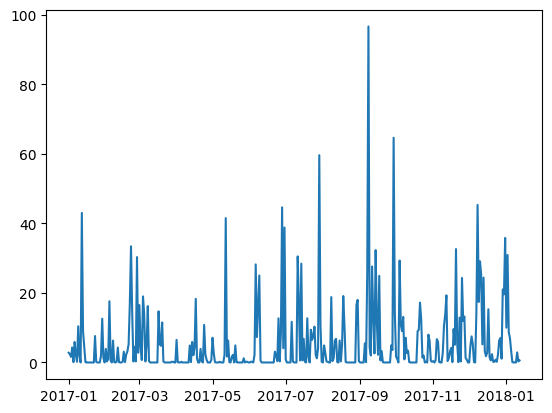

In [11]:
df_filtered = df_rainfall.loc[prima_corrispondenza:]
plt.plot(df_rainfall)

In [12]:
df_weekly = df_filtered.resample('6D', label='left').sum()


In [23]:
display(df_stats.iloc[:3,:])
print(df_stats.columns)
display(df_phenology.iloc[:3,:])

,Date_Band,mean,std,Date,Band,Name,Type
Code,,,,,,,
1841224,20170104_VH,0.846021,0.060364,2017-01-04,VH,DB_A_C,Potatoes
1841224,20170104_VV,0.912519,0.032522,2017-01-04,VV,DB_A_C,Potatoes
1841224,20170110_VH,0.470780,0.095106,2017-01-10,VH,DB_A_C,Potatoes


Index(['Date_Band', 'mean', 'std', 'Date', 'Band', 'Name', 'Type'], dtype='str')


,2017-05-18 00:00:00,2017-05-23 00:00:00,2017-05-30 00:00:00,2017-06-08 00:00:00,2017-06-15 00:00:00,2017-06-21 00:00:00,2017-06-27 00:00:00,2017-07-03 00:00:00,2017-07-06 00:00:00,2017-07-13 00:00:00,2017-07-17 00:00:00,2017-07-27 00:00:00,2017-08-02 00:00:00,2017-08-11 00:00:00,2017-08-17 00:00:00
Code,,,,,,,,,,,,,,,
1545384,NaN,NaN,NaN,NaN,NaN,64.0,66.25,NaN,NaN,69.0,69.0,NaN,NaN,NaN,NaN
1553694,NaN,NaN,NaN,NaN,NaN,18.0,31.50,49.0,NaN,44.0,NaN,NaN,NaN,NaN,NaN
1576641,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
from matplotlib.backends.backend_pdf import PdfPages
# 1. Trasformazione del dizionario in DataFrame (Formato Lungo)
# Definisci il nome del file di uscita

output_folder = Path('/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents')
output_folder.mkdir(parents=True, exist_ok=True)

pdf_filename = output_folder / 'Time_Series_Coherencia_Phenology.pdf'

with PdfPages(pdf_filename) as pdf:
    # Assicurati che l'indice di df_mediato sia stringa per il matching con 'code'
    df_phenology.index = df_phenology.index.astype(str)
    
    # Raggruppiamo df_stats che contiene i dati radar (backscatter)
    for (code, roi_type, name), group in df_stats.groupby(['Code', 'Type', 'Name']):
        code_str = str(code)
        parcel_ratio = df_stats[df_stats.index == code].sort_values('Date')


        # 1. Controllo: il codice deve essere presente nell'indice delle altezze
        if code_str not in df_phenology.index:
            print(f"Salto {code_str}: altezza non trovata nell'indice")
            continue

        fig, ax1 = plt.subplots(figsize=(12, 6))
        
        # --- ASSE 1: BACKSCATTER (da df_stats) ---
        # I valori sigma0 (dB) sono spesso negativi (es. da -5 a -25 dB) 
        for band in group['Band'].unique():
            band_data = group[group['Band'] == band].sort_values('Date')
            ax1.plot(band_data['Date'], band_data['mean'], marker='o', label=f'Cohe {band} (dB)')
        

        # --- ASSE 2: ALTEZZA PIANTA (da df_mediato) ---
        ax2 = ax1.twinx() 
        
        # Estraiamo la riga corrispondente alla parcella
        grow_series = df_phenology.loc[code_str].dropna()
        # Convertiamo i nomi delle colonne (date) in datetime per il filtro temporale
        grow_series.index = pd.to_datetime(grow_series.index)
        
        if not grow_series.empty:
            min_d, max_d = group['Date'].min(), group['Date'].max()
            grow_filt = grow_series.loc[min_d:max_d]
            
            if not grow_filt.empty:
                # Plot dell'altezza (valori positivi in cm) [cite: 381, 557]
                ax2.plot(grow_filt.index, grow_filt.values, 
                        color='forestgreen', linewidth=2, linestyle='--', label='Plant Height (cm)')
        
        ax2.set_ylabel("Phenology Stage ", color='forestgreen', fontweight='bold')
        ax2.tick_params(axis='y', labelcolor='forestgreen')
        ax2.set_ylim(bottom=0) # L'altezza parte da 0 cm

        # --- FINALIZZAZIONE ---
        plt.title(f"Parcel {code_str} ({name}) - {roi_type}")
        ax1.grid(True, alpha=0.3)
        
        # Legenda unificata
        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax1.legend(h1 + h2, l1 + l2, loc='upper left', bbox_to_anchor=(1.1, 1))
        
        plt.setp(ax1.get_xticklabels(), rotation=45)
        plt.subplots_adjust(right=0.75, bottom=0.2)
        
        pdf.savefig(fig)
        plt.close(fig)

Salto 1697689: altezza non trovata nell'indice
Salto 1697690: altezza non trovata nell'indice
Salto 1841224: altezza non trovata nell'indice
